## Learning The Dataset

In [1]:
import pandas as pd

housing_data = pd.read_csv("train.csv")
housing_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


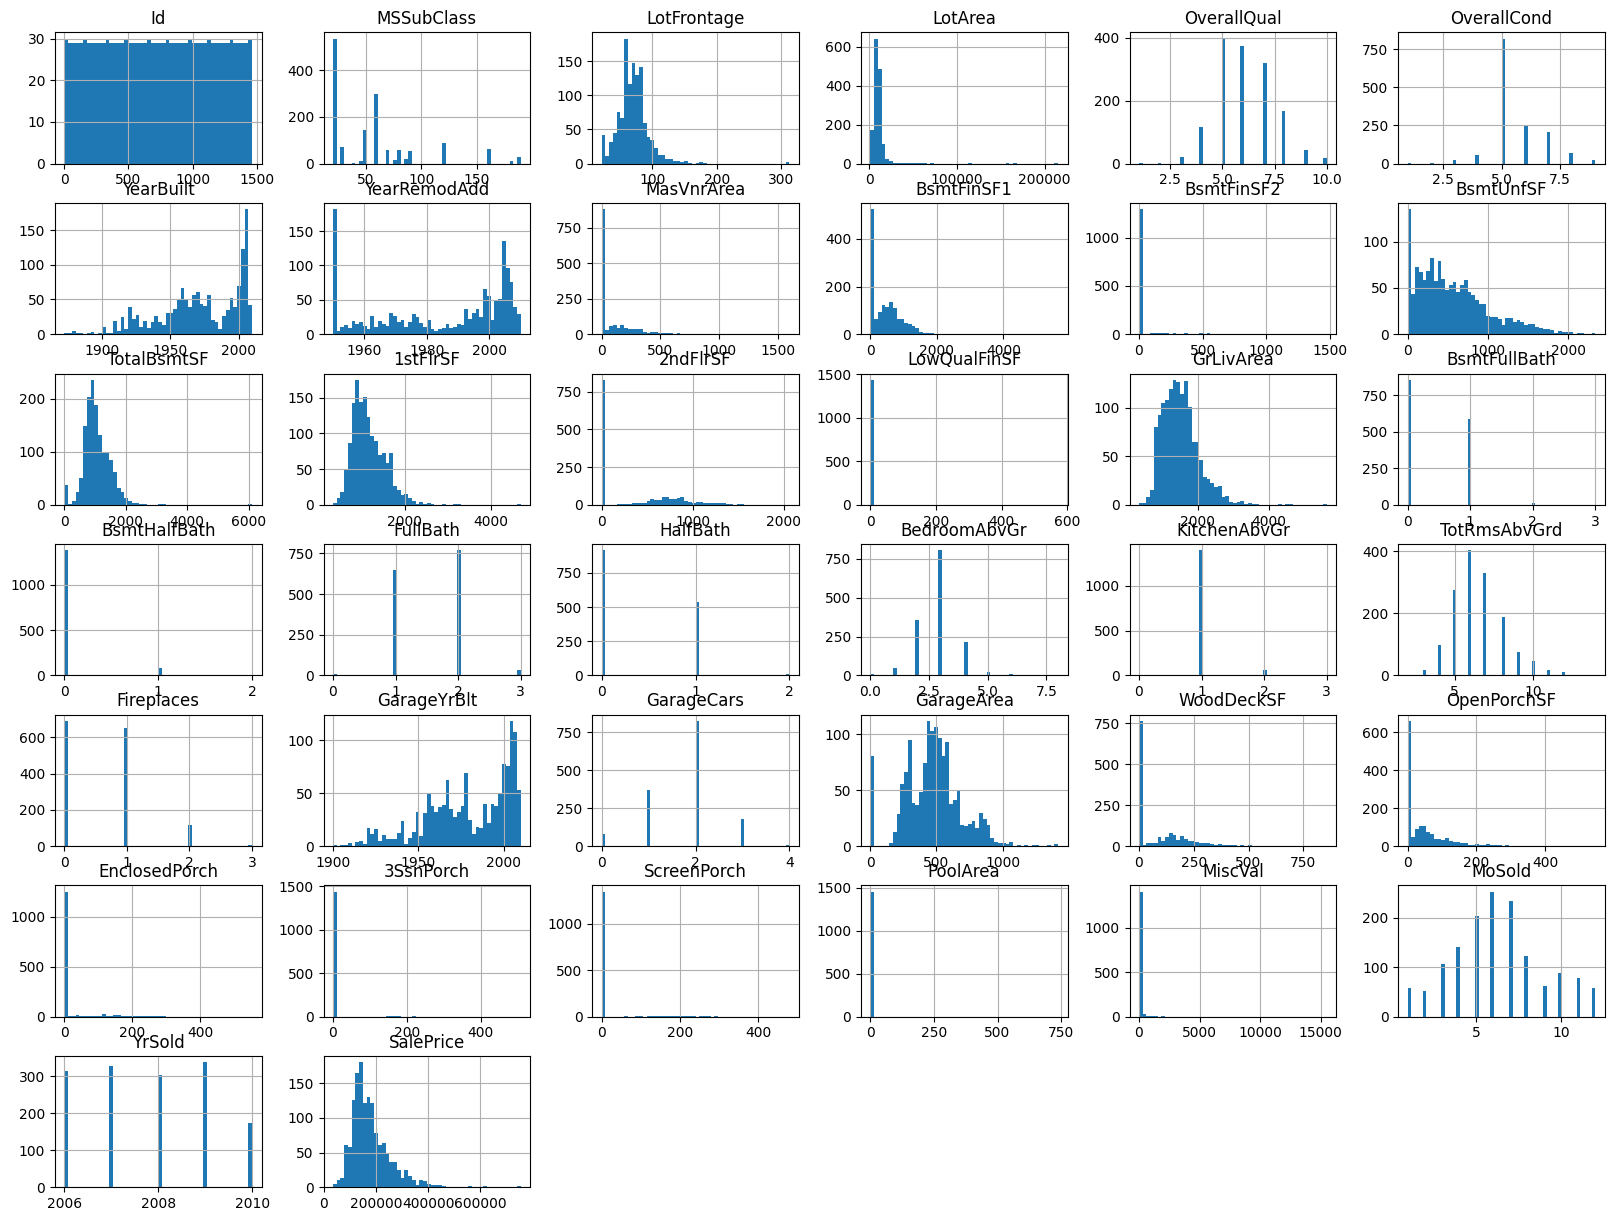

In [2]:
import matplotlib.pyplot as plt
housing_data.hist(bins=50, figsize=(20,15))
plt.show()

In [3]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Splitting Training and Testing Data

### Splitting based on house prices category

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np

saleprice_cat = pd.qcut(housing_data["SalePrice"], q=5, labels= [1, 2, 3, 4, 5])

sss = StratifiedShuffleSplit(n_splits=1, test_size = 0.2, random_state=42)
for train_index, test_index in sss.split(housing_data, saleprice_cat):
    strat_train_set = housing_data.loc[train_index]
    strat_test_set = housing_data.loc[test_index]

## Splitting On Label

In [5]:
training_housing_data = strat_train_set.drop(columns="SalePrice")
training_housing_label = strat_train_set["SalePrice"].copy()

## Preparing The Data

### Simple Imputer (median for numbers and most frequent for objects), target encoding, standard scaler

In [6]:
from sklearn.base import BaseEstimator, TransformerMixin

class CustomTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    # What fit does is to learn parameters for the data
    def fit(self, X, y=None):
        return self
    def transform(self, data):
        data = data.copy()
        data.drop(columns="Id")
        return data

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer

num_attribs = list(training_housing_data.select_dtypes(include="number").columns)
num_attribs.remove('Id')

cat_attribs = list(training_housing_data.select_dtypes(include="object").columns)


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('standard_scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('target', TargetEncoder(random_state=42)),
    ('standard_scaler', StandardScaler())
])

preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', cat_pipeline, cat_attribs)
])

In [8]:
full_pipeline = Pipeline([
    ('custom', CustomTransformer()),
    ('preprocess', preprocessing)
])

training_data = full_pipeline.fit_transform(training_housing_data, training_housing_label)
training_data

D:\Programming\housingPrices\env\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


array([[-0.1515269 , -0.01745034, -0.27655235, ...,  0.72323072,
        -0.2623144 ,  0.72114436],
       [-0.87145947, -0.20530283,  0.34590278, ..., -1.36450946,
        -0.2623144 ,  0.73763854],
       [-0.1515269 ,  0.68699651,  0.02071713, ...,  0.7123774 ,
        -0.2623144 ,  0.71028852],
       ...,
       [-0.63148194, -0.9567128 , -0.55571404, ..., -1.36450946,
        -0.2623144 ,  0.73763854],
       [-0.87145947, -0.01745034,  0.00713629, ..., -1.36450946,
        -0.2623144 ,  0.73763854],
       [ 0.32842814, -0.01745034,  0.00907641, ...,  0.72323072,
        -0.2623144 ,  0.72114436]], shape=(1168, 25578))

In [9]:
ct = full_pipeline.named_steps['preprocess']
final_training_data = pd.DataFrame(
    training_data, columns=ct.get_feature_names_out(), index=training_housing_data.index
)
final_training_data

,num__MSSubClass,num__LotFrontage,num__LotArea,num__OverallQual,num__OverallCond,num__YearBuilt,num__YearRemodAdd,num__MasVnrArea,num__BsmtFinSF1,num__BsmtFinSF2,...,cat__SaleCondition_475000,cat__SaleCondition_485000,cat__SaleCondition_501837,cat__SaleCondition_555000,cat__SaleCondition_556581,cat__SaleCondition_582933,cat__SaleCondition_611657,cat__SaleCondition_625000,cat__SaleCondition_745000,cat__SaleCondition_755000
307,-0.151527,-0.017450,-0.276552,-0.066636,1.245540,-1.688380,-1.675110,-0.556745,-1.003301,-0.294416,...,-1.375045,-0.278936,-0.289570,0.702913,-0.280715,-0.272915,-0.278936,0.723231,-0.262314,0.721144
1341,-0.871459,-0.205303,0.345903,-0.066636,-0.513578,1.059099,0.911750,-0.556745,0.864582,-0.294416,...,0.729224,-0.278936,-0.289570,0.719449,-0.280715,-0.272915,-0.278936,-1.364509,-0.262314,0.737639
1175,-0.151527,0.686997,0.020717,1.361453,-0.513578,0.694975,0.720131,1.280877,0.602987,-0.294416,...,0.701880,-0.278936,-0.289570,-1.390661,-0.280715,-0.272915,-0.278936,0.712377,-0.262314,0.710289
349,0.088451,-0.674934,1.071939,2.075497,-0.513578,1.125303,1.007560,4.187266,2.232222,-0.294416,...,-1.375045,3.716848,3.545103,-1.390661,3.684112,-0.272915,3.716718,-1.364509,-0.262314,-1.367080
621,0.088451,0.921812,0.033867,-0.066636,1.245540,0.099136,0.576416,-0.556745,1.190429,0.793712,...,0.729224,-0.278936,-0.289570,0.719449,-0.280715,-0.272915,-0.278936,-1.364509,-0.262314,0.737639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1356,-0.871459,-0.017450,-0.108732,-0.780680,-0.513578,-0.165681,-0.908633,-0.202308,-0.223104,-0.294416,...,0.729224,-0.278936,-0.289570,0.719449,-0.280715,-0.272915,-0.278936,-1.364509,-0.262314,0.737639
389,0.088451,1.203591,0.214298,2.789541,-0.513578,1.191508,1.103370,0.926440,1.933911,-0.294416,...,-1.375045,3.570068,3.404241,-1.390661,-0.280715,3.677411,3.569942,-1.364509,-0.262314,-1.367080
1323,-0.631482,-0.956713,-0.555714,-1.494725,1.245540,-1.026337,-1.675110,-0.556745,-0.360786,-0.294416,...,0.729224,-0.278936,-0.289570,0.719449,-0.280715,-0.272915,-0.278936,-1.364509,-0.262314,0.737639
33,-0.871459,-0.017450,0.007136,-0.780680,-0.513578,-0.397396,-1.243967,-0.556745,1.332701,-0.294416,...,0.729224,-0.278936,-0.289570,0.719449,-0.280715,-0.272915,-0.278936,-1.364509,-0.262314,0.737639


## Training Model

### Random forest, polynomial regression, GradientBoostingRegressor

In [10]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

gbr = GradientBoostingRegressor()
rf = RandomForestRegressor()
lr = LinearRegression()

In [11]:
def display_scores(scores):
    print("Scores: ", scores)
    print("Mean ", scores.mean())

In [ ]:
from sklearn.model_selection import cross_val_score
gbr_cv = cross_val_score(gbr, final_training_data, training_housing_label, scoring="neg_mean_squared_error", cv=8)
gbr_score = np.sqrt(-gbr_cv)
display_scores(gbr_score)